In [1]:
import pandas as pd

df = pd.read_csv('./data/apple_quality.csv')
df 

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good


In [2]:
df.isnull().sum()
df = df.dropna()
df 

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3995,3995.0,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,bad
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good


In [3]:
def quality_function(x):
    if x == 'good':
        return 1
    elif x == 'bad':
        return 0
    else:
        raise ValueError("Invalid value in quality column")

df["quality_num"] = df["Quality"].apply(quality_function)

/var/folders/qn/3_cqp_vx25v4w6yrx68654q80000gp/T/ipykernel_99035/1216146895.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["quality_num"] = df["Quality"].apply(quality_function)


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop(columns = ["Quality", "quality_num"]) 
y = df["quality_num"]

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=0)

clf = DecisionTreeClassifier(random_state=0, max_depth=8)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_validate)
accuracy = accuracy_score(y_pred, y_validate)
print(accuracy)

0.78375


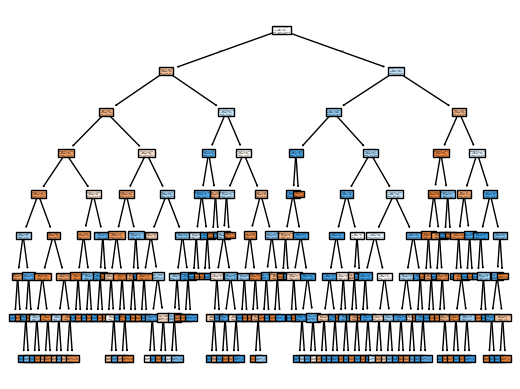

In [5]:
from sklearn.tree import plot_tree
_ = plot_tree(clf, feature_names = X.columns, filled=True, class_names=["bad", "good"])

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X = df.drop(columns = ["Quality", "quality_num"]) 
y = df["quality_num"]

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=0)

prediction_collected = np.zeros(len(y_validate))

N = 100
for i in range(1, N):
    clf = DecisionTreeClassifier(random_state=i, max_depth=20)
    X_bag, _, y_bag, _ = train_test_split(X_train, y_train, test_size=0.2, random_state=i)
    clf.fit(X_bag, y_bag)
    y_pred = clf.predict(X_validate)
    prediction_collected += y_pred



prediction = prediction_collected/N
accuracy = accuracy_score(np.round(prediction), y_validate)
print(accuracy)

0.86625


In [ ]:
from sklearn.ensemble import RandomForestClassifier 

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2)

n_list = list(range(1, 100, 5))

scores = []
for i in n_list:
    rf_clf = RandomForestClassifier(n_estimators=i, random_state=2)
    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_validate)
    score = accuracy_score(y_pred, y_validate)
    scores.append(score)
import matplotlib.pyplot as plt 
plt.plot(n_list, scores)

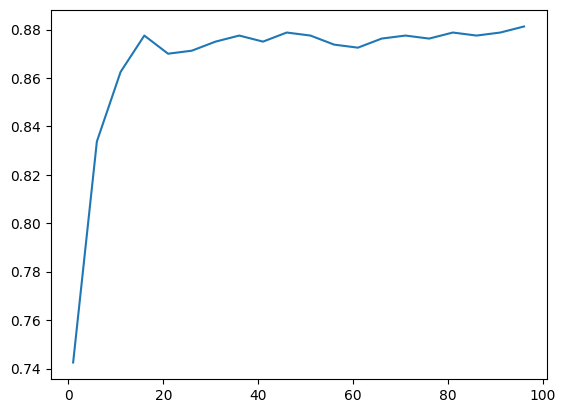